In [37]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
 
from lib.dataset.dataloader import AMSR2Dataset, collate_crop_to_min, collate_pad_to_max
from lib.model.Baseline import CNN
from lib.model.FusionNet import FusionNet
from lib.model.FusionNetRes import FusionNetRes
from lib.model.FusionNetASPP import FusionNetASPP

In [38]:
### Only change these two ###
MODEL_NAME = 'baseline'   # 'baseline' | 'fusionnet' | 'fusionnetres' | 'fusionnetaspp'
postfix    = '1'

### Derived paths ###
BASE_OUTPUT  = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
CACHE_DIR    = '/dmidata/projects/asip-cms/ninna_msc/zarr_cache'
SAR_DIR      = '/dmidata/projects/asip-cms/sentinel1'
OUTPUT_DIR   = os.path.join(BASE_OUTPUT, MODEL_NAME)
CKPT_PATH    = os.path.join(OUTPUT_DIR, f'best_model_{postfix}.pth')
history_path = os.path.join(OUTPUT_DIR, f'training_history_{postfix}.npy')

NUM_WORKERS = 0

 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
 
### Load checkpoint — all model and training params come from here ###
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)

in_channels = ckpt['in_channels']
features    = ckpt['features']
batch_size  = ckpt.get('batch_size',    '?')
lr          = ckpt.get('learning_rate', '?')
wd          = ckpt.get('weight_decay',  '?')
model_name  = ckpt.get('model_name', 'Unknown')
grad_clip   = ckpt.get('grad_clip_norm','?')
collate     = ckpt.get('collate',       '?')
COLLATE_FN  = collate_crop_to_min if collate == 'crop_to_min' else collate_pad_to_max
 
print(f"Checkpoint  : epoch={ckpt['epoch']}  in_channels={in_channels}  features={features}")
print(f"Val metrics : loss={ckpt['val_loss']:.4f}  rmse={ckpt['val_rmse']:.2f}%  mae={ckpt['val_mae']:.2f}%")
print(f"Training    : lr={lr}  batch={batch_size}  wd={wd}  grad_clip={grad_clip}  collate={collate}")
 
### Build model from checkpoint params ###
_mdl = {
    'baseline':       lambda: CNN(in_channels=in_channels, features=features),
    'fusionnet':      lambda: FusionNet(in_channels=in_channels, features=features),
    'fusionnetres':   lambda: FusionNetRes(in_channels=in_channels, features=features),
    'fusionnetaspp':  lambda: FusionNetASPP(in_channels=in_channels, features=features),
}
model = _mdl[model_name.lower()]().to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
 
### Load dataset — batch_size from checkpoint if available ###
bs = batch_size if isinstance(batch_size, int) else 8
val_dataset = AMSR2Dataset(CACHE_DIR, split='val')
val_loader  = DataLoader(
    val_dataset, batch_size=bs, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    collate_fn=COLLATE_FN,
)
 
### Run inference ###
amsr2, sic, mask = next(iter(val_loader))
amsr2, sic, mask = amsr2.to(device), sic.to(device), mask.to(device)
target_size = (sic.shape[-2], sic.shape[-1])
 
with torch.no_grad():
    pred = model(amsr2, target_size=target_size)
 

Using device: cuda
Checkpoint  : epoch=150  in_channels=14  features=32
Val metrics : loss=3.8686  rmse=8.53%  mae=3.87%
Training    : lr=0.0001  batch=32  wd=1e-05  grad_clip=1.0  collate=pad_to_max


In [39]:
SAMPLE_IDX  = 31   # which sample in the batch to plot

### Extract sample ###
idx      = SAMPLE_IDX
amsr2_np = amsr2[idx].cpu().numpy()   # (14, H, W)
sic_np   = sic[idx, 0].cpu().numpy()  # (H, W)
mask_np  = mask[idx, 0].cpu().numpy() # (H, W) bool
pred_np  = pred[idx, 0].cpu().numpy() # (H, W)
# pred_np = np.clip(pred_np, 0, 100)
 
sic_np  = np.where(mask_np, np.nan, sic_np)
pred_np = np.where(mask_np, np.nan, pred_np)
diff_np = pred_np - sic_np

#### Plot

Prediction and AMSR2 channels

Text(0.5, 0.98, 'Baseline  |  AMSR2 inputs (left)  |  SIC target, prediction, error (right)  — sample 31\nEpoch 150  |  val_loss=3.8686  val_rmse=8.53%  val_mae=3.87%  |  lr=0.0001  batch=32  collate=pad_to_max')

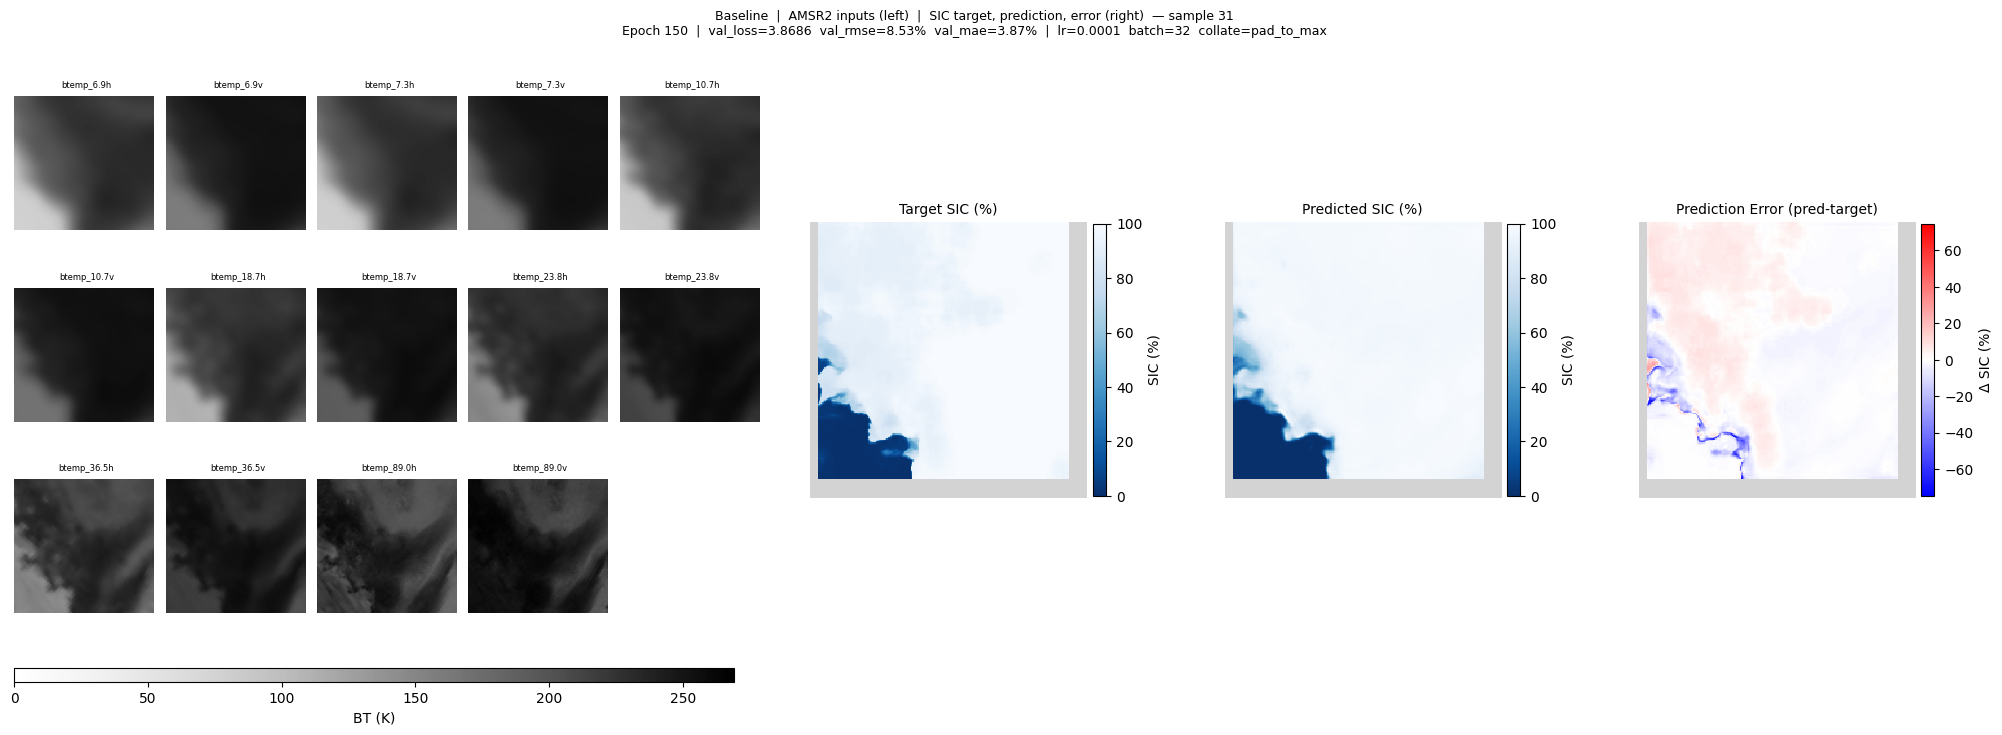

In [40]:
# Prediction
fig = plt.figure(figsize=(20, 7))

channel_names = val_dataset.channel_names  # list of 14 names from zarr attrs
 
cmap_bt   = plt.cm.Greys.copy(); cmap_bt.set_bad('beige')
cmap_sic  = plt.cm.Blues_r.copy();  cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();   cmap_diff.set_bad('lightgray')

gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 3], wspace=0.05,
              left=0.02, right=0.98, top=0.88, bottom=0.08)
gs_amsr2 = gs[0, 0].subgridspec(3, 5, hspace=0.08, wspace=0.05)

ims_amsr2 = []
for i in range(in_channels):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_amsr2[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(channel_names[i] if i < len(channel_names) else f'ch {i}', fontsize=6)
    ax.axis('off')
    ims_amsr2.append(im)

fig.add_subplot(gs_amsr2[2, 4]).axis('off')

vmin_bt = amsr2_np.min()
vmax_bt = amsr2_np.max()
for im in ims_amsr2:
    im.set_clim(vmin_bt, vmax_bt)

cbar_ax = fig.add_axes([0.02, 0.02, 0.36, 0.02])
fig.colorbar(ims_amsr2[0], cax=cbar_ax, orientation='horizontal', label='BT (K)')

gs_sic = gs[0, 1].subgridspec(1, 3, wspace=0.4)
vmin, vmax = 0, 100

ax0 = fig.add_subplot(gs_sic[0, 0])
im0 = ax0.imshow(sic_np, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax0.set_title('Target SIC (%)', fontsize=10)
ax0.axis('off')
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02, label='SIC (%)')

ax1 = fig.add_subplot(gs_sic[0, 1])
im1 = ax1.imshow(pred_np, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax1.set_title('Predicted SIC (%)', fontsize=10)
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02, label='SIC (%)')

abs_max = np.nanmax(np.abs(diff_np))
ax2 = fig.add_subplot(gs_sic[0, 2])
im2 = ax2.imshow(diff_np, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax2.set_title('Prediction Error (pred-target)', fontsize=10)
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02, label='Δ SIC (%)')

fig.suptitle(
    f'{model_name}  |  AMSR2 inputs (left)  |  SIC target, prediction, error (right)  — sample {idx}\n'
    f'Epoch {ckpt["epoch"]}  |  '
    f'val_loss={ckpt["val_loss"]:.4f}  val_rmse={ckpt["val_rmse"]:.2f}%  val_mae={ckpt["val_mae"]:.2f}%  |  '
    f'lr={lr}  batch={batch_size}  collate={collate}',
    fontsize=9,
)

Training curves

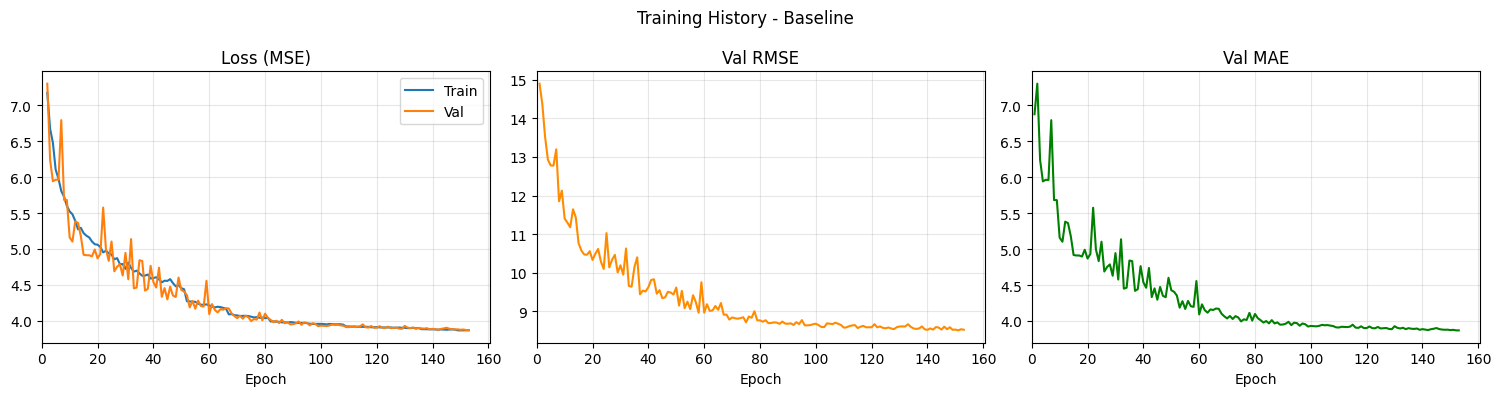

In [41]:
# Training curves
history = np.load(history_path, allow_pickle=True).item() # load history dict
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs[1:], history['train_loss'][1:], label='Train')
axes[0].plot(epochs[1:], history['val_loss'][1:], label='Val')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_xlim(0)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_rmse'], color='darkorange')
axes[1].set_title('Val RMSE')
axes[1].set_xlabel('Epoch')
axes[1].set_xlim(0)
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_mae'], color='green')
axes[2].set_title('Val MAE')
axes[2].set_xlabel('Epoch')
axes[2].set_xlim(0)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Training History - {model_name}')
plt.tight_layout()
# history_png_path = os.path.join(OUTPUT_DIR, 'training_curves.png')
# plt.savefig(history_png_path, dpi=150, bbox_inches='tight')
# plt.close()
# print(f"Training curves figure saved to {history_png_path}")

Prediction with corresponding SAR image

In [42]:
idx = SAMPLE_IDX  # which sample in the batch
TRAINING_INDEX_CSV = "/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/training_index.csv"

# Get the SIC filename for this val sample
_, val_files = train_test_split(
    pd.read_csv(TRAINING_INDEX_CSV)[['amsr2_file', 'sic_file', 'timestamp']],
    test_size=0.2, random_state=42, shuffle=True
)
val_files = val_files.reset_index(drop=True)

sic_file  = val_files.iloc[idx]['sic_file']
timestamp = val_files.iloc[idx]['timestamp']
y, m, d   = str(timestamp)[:4], str(timestamp)[5:7], str(timestamp)[8:10]

sar_filename = sic_file.replace('_SIC.tiff', '.zip')
sar_path     = os.path.join('/dmidata/projects/asip-cms/sentinel1', y, m, d, sar_filename)
print(f'SAR path: {sar_path}')

SAR path: /dmidata/projects/asip-cms/sentinel1/2018/07/21/S1B_EW_GRDM_1SDH_20180721T075143_20180721T075243_011906_015EA5_12CF.zip


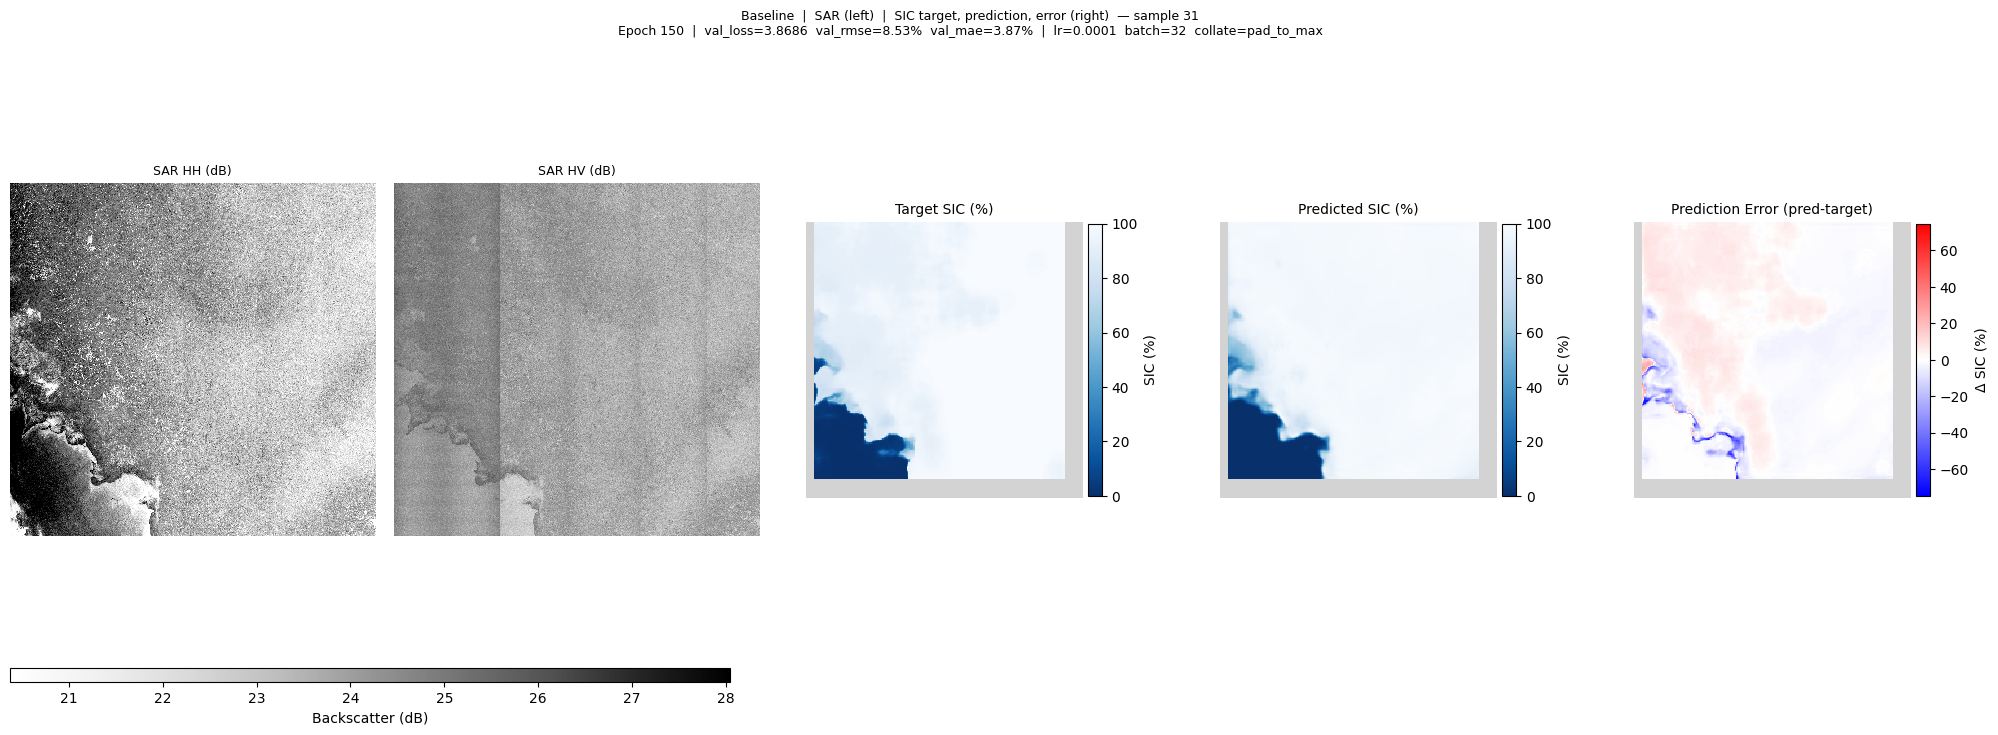

In [43]:
# Prediction
import zipfile
import rioxarray

# Load SAR HH and HV from zip
with zipfile.ZipFile(sar_path, 'r') as z:
    tiff_files = sorted([f for f in z.namelist() if 'measurement' in f and f.endswith('.tiff')])
    
    # Read HH
    with z.open(tiff_files[0]) as f:
        import io
        hh_bytes = io.BytesIO(f.read())
    with rioxarray.open_rasterio(hh_bytes) as da:
        hh = da.values[0].astype(np.float32)

    # Read HV
    with z.open(tiff_files[1]) as f:
        hv_bytes = io.BytesIO(f.read())
    with rioxarray.open_rasterio(hv_bytes) as da:
        hv = da.values[0].astype(np.float32)

# Convert to dB
def to_db(arr):
    arr = arr.astype(np.float32)
    arr[arr <= 0] = np.nan
    return 10 * np.log10(arr)

hh_db = to_db(hh)
hv_db = to_db(hv)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 7))

cmap_sar  = plt.cm.Greys.copy();  cmap_sar.set_bad('beige')
cmap_sic  = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();   cmap_diff.set_bad('lightgray')

gs      = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 3], wspace=0.05,
                            left=0.02, right=0.98, top=0.88, bottom=0.08)
gs_sar  = gs[0, 0].subgridspec(1, 2, hspace=0.05, wspace=0.05)
gs_sic  = gs[0, 1].subgridspec(1, 3, wspace=0.4)

# HH
ax_hh = fig.add_subplot(gs_sar[0, 0])
im_hh = ax_hh.imshow(hh_db, cmap=cmap_sar, interpolation='nearest',
                     vmin=np.nanpercentile(hh_db, 2), vmax=np.nanpercentile(hh_db, 98))
ax_hh.set_title('SAR HH (dB)', fontsize=9)
ax_hh.axis('off')

# HV
ax_hv = fig.add_subplot(gs_sar[0, 1])
im_hv = ax_hv.imshow(hv_db, cmap=cmap_sar, interpolation='nearest')#,
                    #  vmin=np.nanpercentile(hv_db, 2), vmax=np.nanpercentile(hv_db, 98))
ax_hv.set_title('SAR HV (dB)', fontsize=9)
ax_hv.axis('off')

# Shared SAR colorbar
cbar_ax = fig.add_axes([0.02, 0.02, 0.36, 0.02])
fig.colorbar(im_hh, cax=cbar_ax, orientation='horizontal', label='Backscatter (dB)')

# SIC target
vmin, vmax = 0, 100
ax0 = fig.add_subplot(gs_sic[0, 0])
im0 = ax0.imshow(sic_np, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax0.set_title('Target SIC (%)', fontsize=10)
ax0.axis('off')
plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02, label='SIC (%)')

# Predicted SIC
ax1 = fig.add_subplot(gs_sic[0, 1])
im1 = ax1.imshow(pred_np, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax1.set_title('Predicted SIC (%)', fontsize=10)
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.02, label='SIC (%)')

# Error
abs_max = np.nanmax(np.abs(diff_np))
ax2 = fig.add_subplot(gs_sic[0, 2])
im2 = ax2.imshow(diff_np, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax2.set_title('Prediction Error (pred-target)', fontsize=10)
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02, label='Δ SIC (%)')

fig.suptitle(
    f'{model_name}  |  SAR (left)  |  SIC target, prediction, error (right)  — sample {idx}\n'
    f'Epoch {ckpt["epoch"]}  |  '
    f'val_loss={ckpt["val_loss"]:.4f}  val_rmse={ckpt["val_rmse"]:.2f}%  val_mae={ckpt["val_mae"]:.2f}%  |  '
    f'lr={lr}  batch={batch_size}  collate={collate}',
    fontsize=9,
)
plt.show()

#### Comparison of two training runs for same model

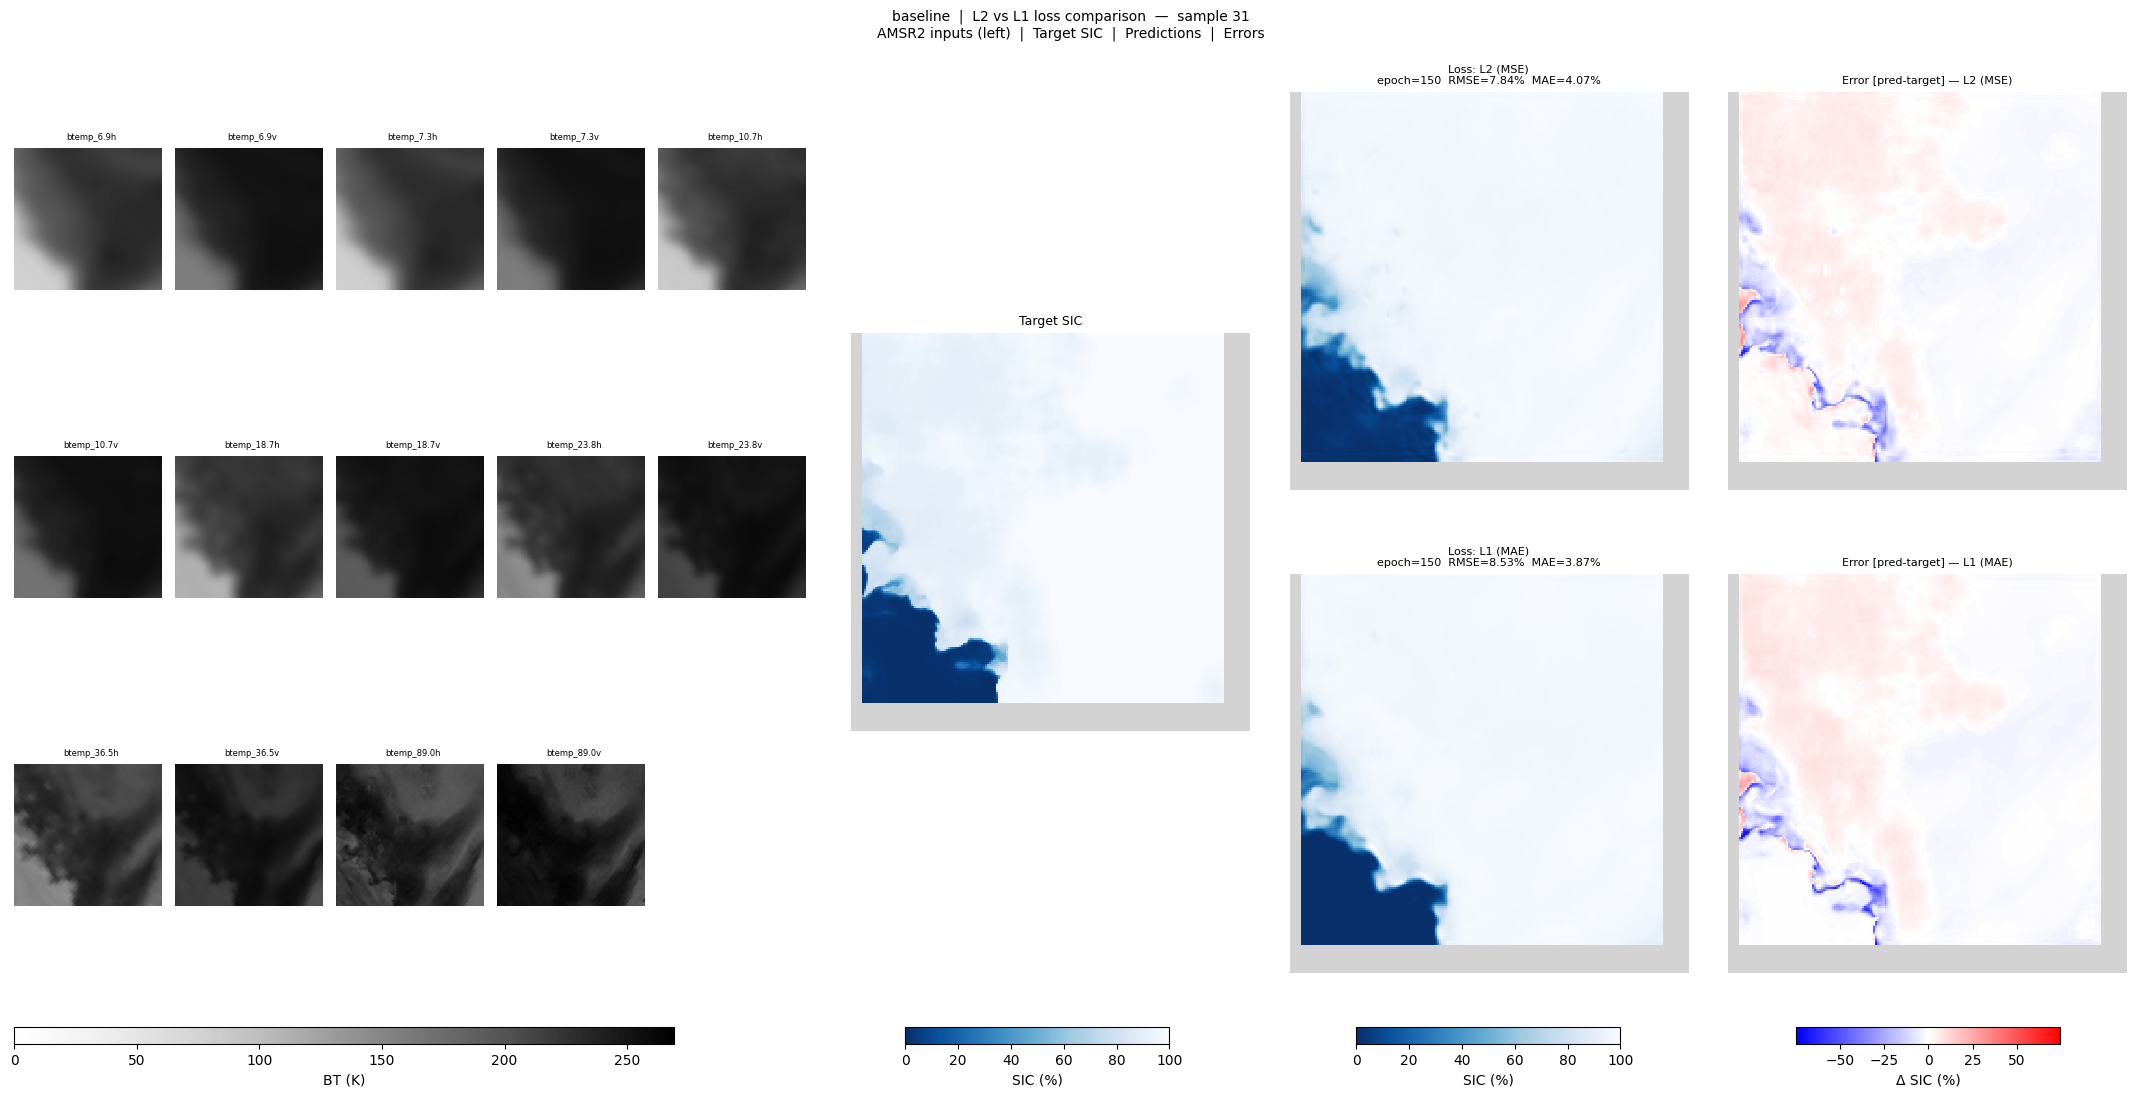

In [44]:
# ── Comparison plot: L2 vs L1 loss predictions ───────────────────────────────
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME  = MODEL_NAME
POSTFIX_L2  = '2'
POSTFIX_L1  = '1'
SAMPLE_IDX  = 31

BASE_OUTPUT = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/outputs/training'
CACHE_DIR   = '/dmidata/projects/asip-cms/ninna_msc/zarr_cache'
OUTPUT_DIR  = os.path.join(BASE_OUTPUT, MODEL_NAME)
device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load both checkpoints ─────────────────────────────────────────────────────
def load_model(postfix):
    ckpt_path = os.path.join(OUTPUT_DIR, f'best_model_{postfix}.pth')
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    _registry = {
        'baseline':      lambda: CNN(in_channels=ckpt['in_channels'], features=ckpt['features']),
        'fusionnet':     lambda: FusionNet(in_channels=ckpt['in_channels'], features=ckpt['features']),
        'fusionnetres':  lambda: FusionNetRes(in_channels=ckpt['in_channels'], features=ckpt['features']),
        'fusionnetaspp': lambda: FusionNetASPP(in_channels=ckpt['in_channels'], features=ckpt['features']),
    }
    model = _registry[MODEL_NAME]().to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt

model_l2, ckpt_l2 = load_model(POSTFIX_L2)
model_l1, ckpt_l1 = load_model(POSTFIX_L1)

# ── Load val batch ────────────────────────────────────────────────────────────
collate_fn = collate_crop_to_min if ckpt_l2.get('collate') == 'crop_to_min' else collate_pad_to_max
bs = ckpt_l2.get('batch_size', 32) if isinstance(ckpt_l2.get('batch_size'), int) else 32
val_dataset = AMSR2Dataset(CACHE_DIR, split='val')
val_loader  = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=0, collate_fn=collate_fn)

amsr2, sic, mask = next(iter(val_loader))
amsr2, sic, mask = amsr2.to(device), sic.to(device), mask.to(device)
target_size = (sic.shape[-2], sic.shape[-1])

with torch.no_grad():
    pred_l2 = model_l2(amsr2, target_size=target_size)
    pred_l1 = model_l1(amsr2, target_size=target_size)

idx      = SAMPLE_IDX
amsr2_np = amsr2[idx].cpu().numpy()
sic_np   = sic[idx, 0].cpu().numpy()
mask_np  = mask[idx, 0].cpu().numpy()
p_l2     = pred_l2[idx, 0].cpu().numpy()
p_l1     = pred_l1[idx, 0].cpu().numpy()

sic_np = np.where(mask_np, np.nan, sic_np)
p_l2   = np.where(mask_np, np.nan, p_l2)
p_l1   = np.where(mask_np, np.nan, p_l1)
d_l2   = p_l2 - sic_np
d_l1   = p_l1 - sic_np

channel_names = val_dataset.channel_names
in_channels   = amsr2_np.shape[0]

# ── Colormaps ─────────────────────────────────────────────────────────────────
cmap_bt   = plt.cm.Greys.copy();   cmap_bt.set_bad('beige')
cmap_sic  = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();     cmap_diff.set_bad('lightgray')
vmin, vmax = 0, 100
abs_max = np.nanmax(np.abs(np.concatenate([d_l2[~np.isnan(d_l2)], d_l1[~np.isnan(d_l1)]])))
vmin_bt, vmax_bt = amsr2_np.min(), amsr2_np.max()

# ── Figure layout ─────────────────────────────────────────────────────────────
# 4 columns: AMSR2 | Target | Predictions (L2 top, L1 bottom) | Diffs (L2 top, L1 bottom)
# Each column gets a shared colorbar at the bottom
fig = plt.figure(figsize=(22, 11))

gs_outer = gridspec.GridSpec(1, 4, figure=fig,
                              width_ratios=[2.2, 1.1, 1.1, 1.1],
                              left=0.02, right=0.98, top=0.91, bottom=0.10,
                              wspace=0.08)

# ── Col 0: AMSR2 channels ────────────────────────────────────────────────────
gs_amsr2 = gs_outer[0, 0].subgridspec(3, 5, hspace=0.12, wspace=0.05)
ims_bt = []
for i in range(in_channels):
    row, col = divmod(i, 5)
    ax = fig.add_subplot(gs_amsr2[row, col])
    im = ax.imshow(amsr2_np[i], cmap=cmap_bt, interpolation='nearest')
    ax.set_title(channel_names[i] if i < len(channel_names) else f'ch {i}', fontsize=6)
    ax.axis('off')
    ims_bt.append(im)
fig.add_subplot(gs_amsr2[2, 4]).axis('off')
for im in ims_bt:
    im.set_clim(vmin_bt, vmax_bt)

# Colorbar bottom of col 0
cax0 = fig.add_axes([0.02, 0.04, 0.30, 0.015])
fig.colorbar(ims_bt[0], cax=cax0, orientation='horizontal', label='BT (K)')

# ── Col 1: Target SIC ────────────────────────────────────────────────────────
ax_tgt = fig.add_subplot(gs_outer[0, 1])
im_tgt = ax_tgt.imshow(sic_np, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax_tgt.set_title('Target SIC', fontsize=9)
ax_tgt.axis('off')

# Colorbar bottom of col 1
cax1 = fig.add_axes([0.425, 0.04, 0.12, 0.015])
fig.colorbar(im_tgt, cax=cax1, orientation='horizontal', label='SIC (%)')

# ── Col 2: Predictions (L2 top, L1 bottom) ───────────────────────────────────
gs_pred = gs_outer[0, 2].subgridspec(2, 1, hspace=0.18)

ax_p2 = fig.add_subplot(gs_pred[0])
im_p2 = ax_p2.imshow(p_l2, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax_p2.set_title(f'Loss: L2 (MSE)\nepoch={ckpt_l2["epoch"]}  RMSE={ckpt_l2["val_rmse"]:.2f}%  MAE={ckpt_l2["val_mae"]:.2f}%', fontsize=8)
ax_p2.axis('off')

ax_p1 = fig.add_subplot(gs_pred[1])
im_p1 = ax_p1.imshow(p_l1, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax_p1.set_title(f'Loss: L1 (MAE)\nepoch={ckpt_l1["epoch"]}  RMSE={ckpt_l1["val_rmse"]:.2f}%  MAE={ckpt_l1["val_mae"]:.2f}%', fontsize=8)
ax_p1.axis('off')

# Shared colorbar bottom of col 2
cax2 = fig.add_axes([0.630, 0.04, 0.12, 0.015])
fig.colorbar(im_p2, cax=cax2, orientation='horizontal', label='SIC (%)')

# ── Col 3: Diffs (L2 top, L1 bottom) ─────────────────────────────────────────
gs_diff = gs_outer[0, 3].subgridspec(2, 1, hspace=0.18)

ax_d2 = fig.add_subplot(gs_diff[0])
im_d2 = ax_d2.imshow(d_l2, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax_d2.set_title('Error [pred-target] — L2 (MSE)', fontsize=8)
ax_d2.axis('off')

ax_d1 = fig.add_subplot(gs_diff[1])
im_d1 = ax_d1.imshow(d_l1, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax_d1.set_title('Error [pred-target] — L1 (MAE)', fontsize=8)
ax_d1.axis('off')

# Shared colorbar bottom of col 3
cax3 = fig.add_axes([0.830, 0.04, 0.12, 0.015])
fig.colorbar(im_d2, cax=cax3, orientation='horizontal', label='Δ SIC (%)')

fig.suptitle(
    f'{MODEL_NAME}  |  L2 vs L1 loss comparison  —  sample {idx}\n'
    f'AMSR2 inputs (left)  |  Target SIC  |  Predictions  |  Errors',
    fontsize=10,
)
plt.show()

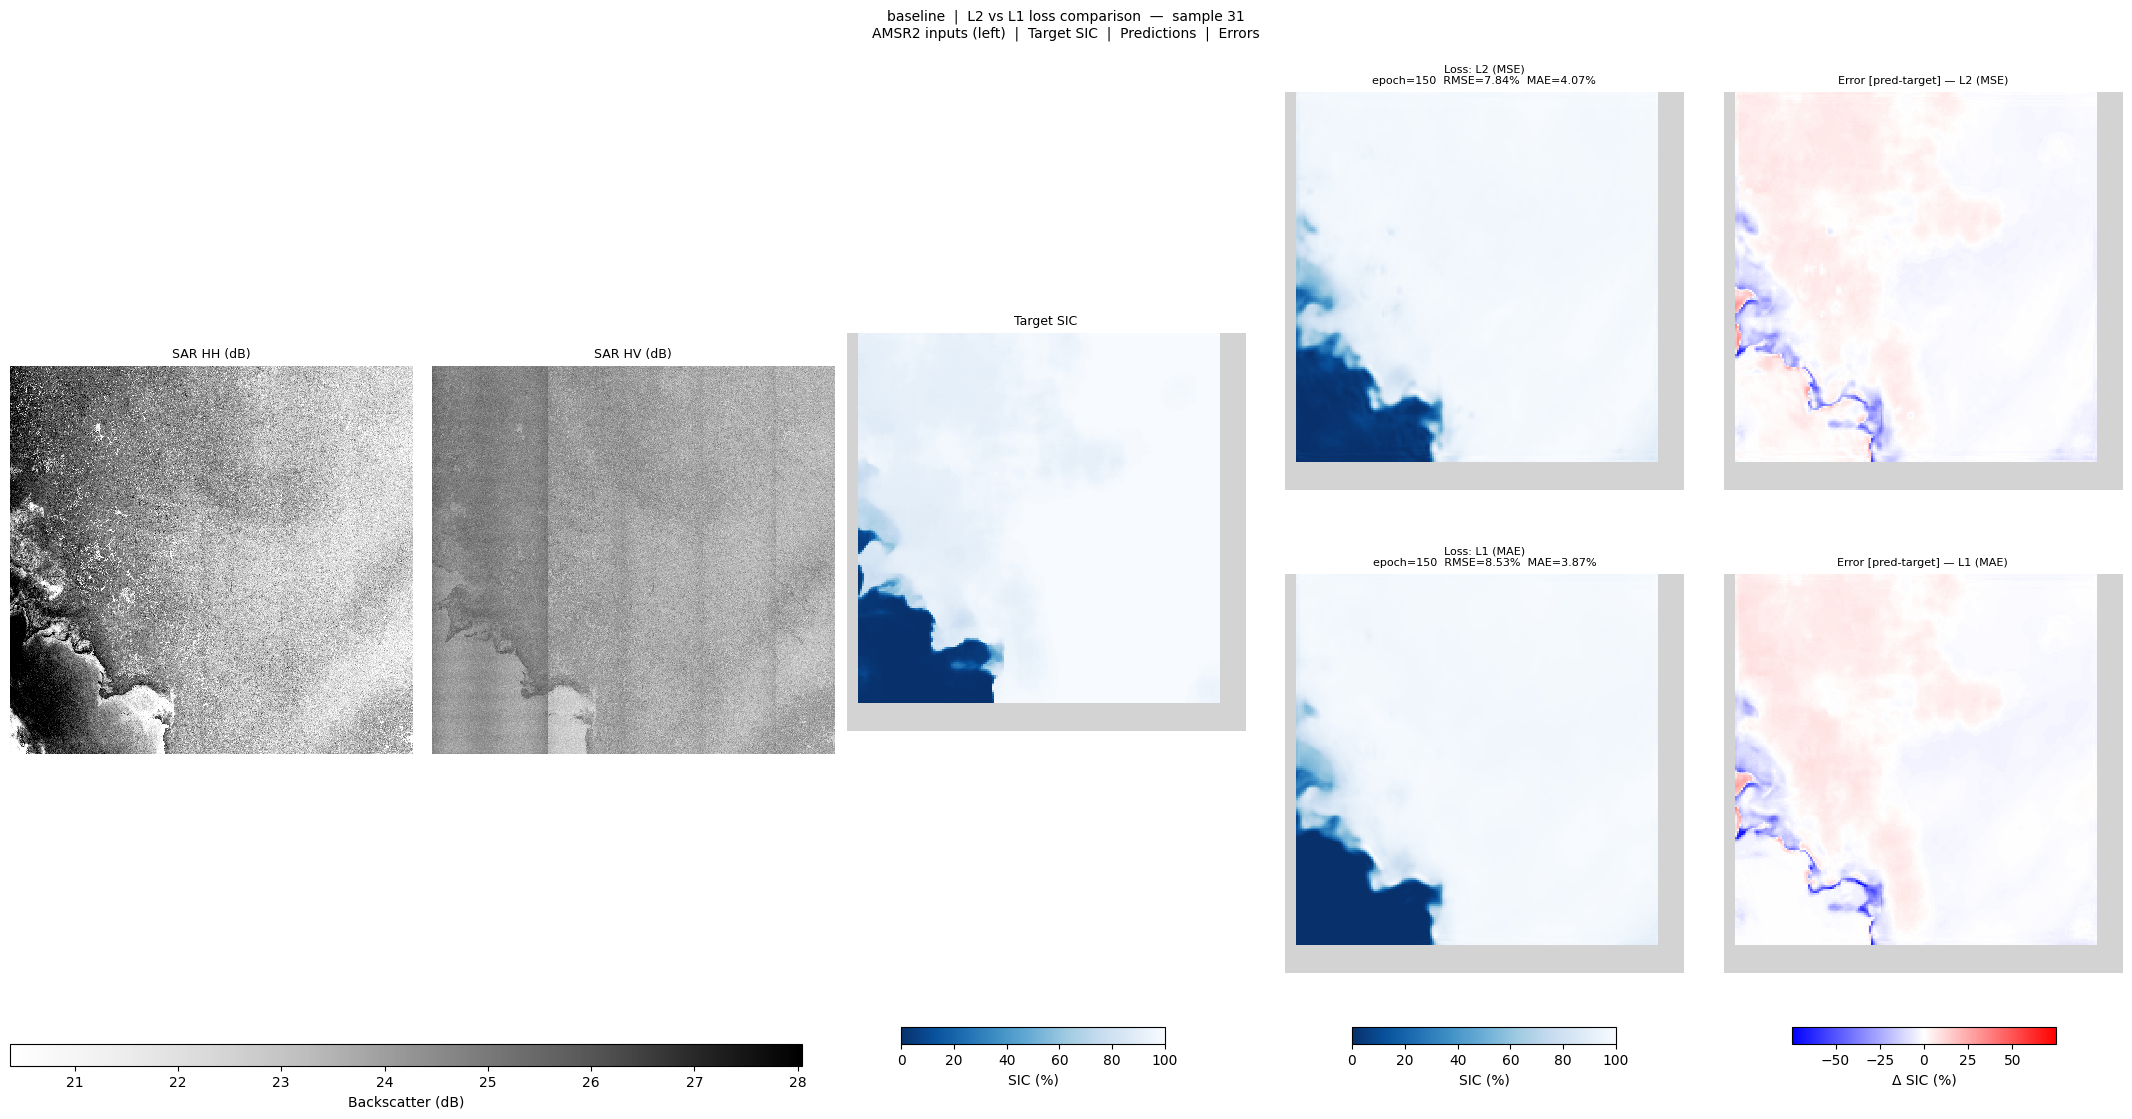

In [45]:
# Comparison with SAR
# ── Figure layout ─────────────────────────────────────────────────────────────
# 4 columns: AMSR2 | Target | Predictions (L2 top, L1 bottom) | Diffs (L2 top, L1 bottom)
# Each column gets a shared colorbar at the bottom
fig = plt.figure(figsize=(22, 11))

gs_outer = gridspec.GridSpec(1, 4, figure=fig,
                              width_ratios=[2.2, 1.1, 1.1, 1.1],
                              left=0.02, right=0.98, top=0.91, bottom=0.10,
                              wspace=0.08)

# ── Col 0: SAR ────────────────────────────────────────────────────
gs_sar  = gs[0, 0].subgridspec(1, 2, hspace=0.05, wspace=0.05)
# HH
ax_hh = fig.add_subplot(gs_sar[0, 0])
im_hh = ax_hh.imshow(hh_db, cmap=cmap_sar, interpolation='nearest',
                     vmin=np.nanpercentile(hh_db, 2), vmax=np.nanpercentile(hh_db, 98))
ax_hh.set_title('SAR HH (dB)', fontsize=9)
ax_hh.axis('off')

# HV
ax_hv = fig.add_subplot(gs_sar[0, 1])
im_hv = ax_hv.imshow(hv_db, cmap=cmap_sar, interpolation='nearest')#,
                    #  vmin=np.nanpercentile(hv_db, 2), vmax=np.nanpercentile(hv_db, 98))
ax_hv.set_title('SAR HV (dB)', fontsize=9)
ax_hv.axis('off')

# Shared SAR colorbar
cbar_ax = fig.add_axes([0.02, 0.02, 0.36, 0.02])
fig.colorbar(im_hh, cax=cbar_ax, orientation='horizontal', label='Backscatter (dB)')

# ── Col 1: Target SIC ────────────────────────────────────────────────────────
ax_tgt = fig.add_subplot(gs_outer[0, 1])
im_tgt = ax_tgt.imshow(sic_np, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax_tgt.set_title('Target SIC', fontsize=9)
ax_tgt.axis('off')

# Colorbar bottom of col 1
cax1 = fig.add_axes([0.425, 0.04, 0.12, 0.015])
fig.colorbar(im_tgt, cax=cax1, orientation='horizontal', label='SIC (%)')

# ── Col 2: Predictions (L2 top, L1 bottom) ───────────────────────────────────
gs_pred = gs_outer[0, 2].subgridspec(2, 1, hspace=0.18)

ax_p2 = fig.add_subplot(gs_pred[0])
im_p2 = ax_p2.imshow(p_l2, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax_p2.set_title(f'Loss: L2 (MSE)\nepoch={ckpt_l2["epoch"]}  RMSE={ckpt_l2["val_rmse"]:.2f}%  MAE={ckpt_l2["val_mae"]:.2f}%', fontsize=8)
ax_p2.axis('off')

ax_p1 = fig.add_subplot(gs_pred[1])
im_p1 = ax_p1.imshow(p_l1, cmap=cmap_sic, vmin=vmin, vmax=vmax, interpolation='nearest')
ax_p1.set_title(f'Loss: L1 (MAE)\nepoch={ckpt_l1["epoch"]}  RMSE={ckpt_l1["val_rmse"]:.2f}%  MAE={ckpt_l1["val_mae"]:.2f}%', fontsize=8)
ax_p1.axis('off')

# Shared colorbar bottom of col 2
cax2 = fig.add_axes([0.630, 0.04, 0.12, 0.015])
fig.colorbar(im_p2, cax=cax2, orientation='horizontal', label='SIC (%)')

# ── Col 3: Diffs (L2 top, L1 bottom) ─────────────────────────────────────────
gs_diff = gs_outer[0, 3].subgridspec(2, 1, hspace=0.18)

ax_d2 = fig.add_subplot(gs_diff[0])
im_d2 = ax_d2.imshow(d_l2, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax_d2.set_title('Error [pred-target] — L2 (MSE)', fontsize=8)
ax_d2.axis('off')

ax_d1 = fig.add_subplot(gs_diff[1])
im_d1 = ax_d1.imshow(d_l1, cmap=cmap_diff, vmin=-abs_max, vmax=abs_max, interpolation='nearest')
ax_d1.set_title('Error [pred-target] — L1 (MAE)', fontsize=8)
ax_d1.axis('off')

# Shared colorbar bottom of col 3
cax3 = fig.add_axes([0.830, 0.04, 0.12, 0.015])
fig.colorbar(im_d2, cax=cax3, orientation='horizontal', label='Δ SIC (%)')

fig.suptitle(
    f'{MODEL_NAME}  |  L2 vs L1 loss comparison  —  sample {idx}\n'
    f'AMSR2 inputs (left)  |  Target SIC  |  Predictions  |  Errors',
    fontsize=10,
)
plt.show()